# Accelerating star

In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from exogaia.data import GaiaAstrometry
from exogaia.leastsq import LeastSquares
from exogaia.models import KeplerModel

In [3]:
source_id = 6199395656645840384  # HD 135344 A
primary_mass = (2.2, 0.1)  # (Msun)

In [4]:
mass_2 = 0.05  # (Msun)
flux_ratio = 0.0

In [5]:
epoch_astrom = GaiaAstrometry(primary_mass=primary_mass, gaia_release='DR4')


Gaia astrometry

Gaia release: DR4
Reference epoch: J2017.500

Primary mass (Msun): 2.20 +/- 0.10


In [6]:
star_param = epoch_astrom.query_source(source_id=source_id, gaia_release='DR3')


---------------
Querying source
---------------

Gaia release: DR3
Source ID: 6199395656645840384

INFO: Query finished. [astroquery.utils.tap.core]

RA = 228.954 deg +/- 0.038 mas
Dec = -37.149 deg +/- 0.026 mas
Parallax = 7.411 +/- 0.040 mas
Proper motion in RA = -18.738 +/- 0.051 mas/yr
Proper motion in Dec = -24.008 +/- 0.035 mas/yr
G-band magnitude = 7.748
Pseudocolor = 1.73 um-1

UWE = 1.96
RUWE = 0.95
Astrometric excess noise (mas) = 0.2075 +/- 0.0103
Non single star = 0


In [7]:
model_param = {
    'ecc': 0.0,
    'tau': 0.5,
    'inc': np.radians(30.),
    'aop': np.radians(0.),
    'pan': np.radians(90.),
    'sma': 7.,
}

In [8]:
model_param = epoch_astrom.simulate_data(
    model_param=model_param,
    mass_2=mass_2,
    flux_ratio=flux_ratio,
    occ_rate=None,
    sigma_per_ccd=None,
    csv_out=None,
    seed=1,
    reject_fraction=False,
)


-------------
Simulate data
-------------

System type: binary

Primary mass (Msun): 2.20 +/- 0.10

AL scan uncertainty (per CCD) = 193.14 uas
AL scan uncertainty (per transit) = 68.29 uas

Additional parameters:
   - Primary mass (Msun) = 2.20
   - Companion mass (Msun) = 5.00e-02
   - Mass ratio = 2.27e-02
   - Flux ratio = 0.00e+00
   - Relative semi-major axis (au) = 7.00

Star model

Epoch astrometry: GaiaAstrometry

-----------------------
Calculate stellar track
-----------------------

Stellar parameters:
   - RA offset (mas) = 0.000
   - Dec offset (mas) = 0.000
   - Parallax (mas) = 7.411
   - Proper motion in RA (mas/yr) = -18.738
   - Proper motion in Dec (mas/yr) = -24.008

Kepler model

Epoch astrometry: GaiaAstrometry

---------------------
Calculate orbit model
---------------------

Orbit parameters:
   - Period (days) = 4509.683
   - Eccentricity = 0.000
   - Relative time of periastron = 0.500
   - Semi-major axis (mas) = 51.874
   - Inclination (deg) = 30.000
   - 

In [9]:
leastsq = LeastSquares(epoch_astrometry=epoch_astrom)


--------------------------
Binary star (7 parameters)
--------------------------

Reduced chi^2 = 1.741
RUWE = 1.320
F2 estimator = 4.136
Inflation factor = 1.324
Significance dmu/dt = 15.570

Best-fit parameters:
   - RA offset = 1.134 +/- 0.025 mas
   - Dec offset = -0.038 +/- 0.019 mas
   - Parallax = 7.422 +/- 0.019 mas
   - mu in RA = -18.736 +/- 0.011 mas/yr
   - mu in Dec = -24.401 +/- 0.006 mas/yr
   - dmu/dt in RA = -0.251 +/- 0.016 mas/yr^2
   - dmu/dt in Dec = 0.007 +/- 0.008 mas/yr^2


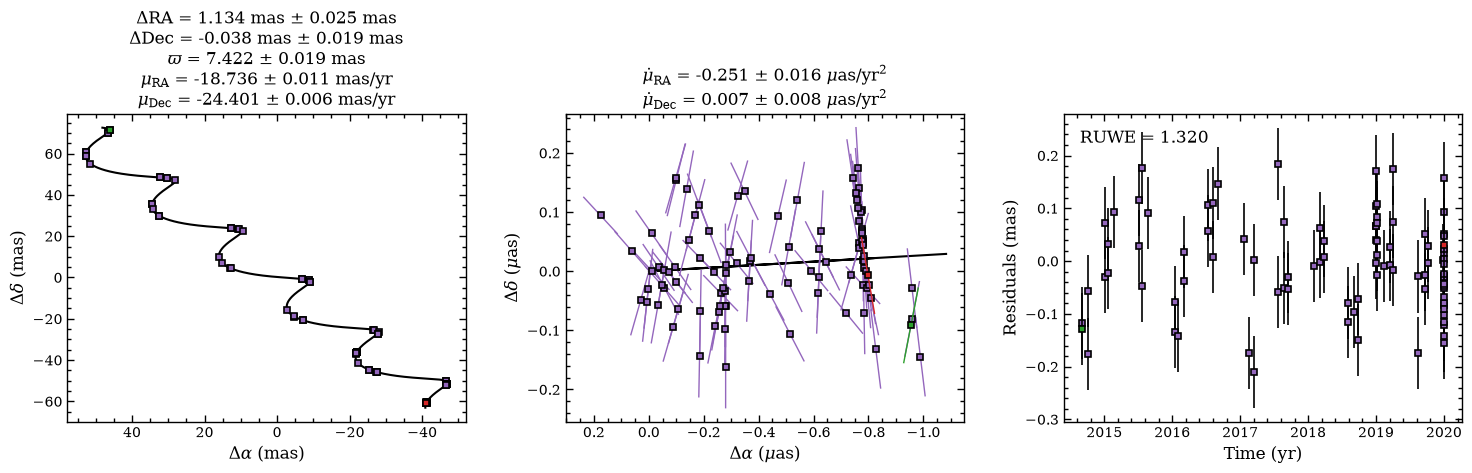

In [10]:
results = leastsq.accel_7param(plot_file='plot.png')

The RUWE is 1.3 when including the acceleration and the significance on $\frac{d \mu}{dt}$ is high. Let's check if the data also warrants including the acceleration derivative, so the second-order derivative of the proper motion.


--------------------------
Binary star (9 parameters)
--------------------------

Reduced chi^2 = 0.985
RUWE = 0.993
F2 estimator = -0.049
Inflation factor = 0.996
Significance dmu/dt = 18.429
Significance d^2mu/d^2t = 8.368

Best-fit parameters:
   - RA offset = 1.134 +/- 0.022 mas
   - Dec offset = 0.002 +/- 0.017 mas
   - Parallax = 7.409 +/- 0.017 mas
   - mu in RA = -18.732 +/- 0.024 mas/yr
   - mu in Dec = -24.517 +/- 0.015 mas/yr
   - dmu/dt in RA = -0.267 +/- 0.015 mas/yr^2
   - dmu/dt in Dec = -0.003 +/- 0.007 mas/yr^2
   - d^2mu/d^2t in RA = -0.009 +/- 0.032 mas/yr^3
   - d^2mu/d^2t in Dec = 0.126 +/- 0.015 mas/yr^3


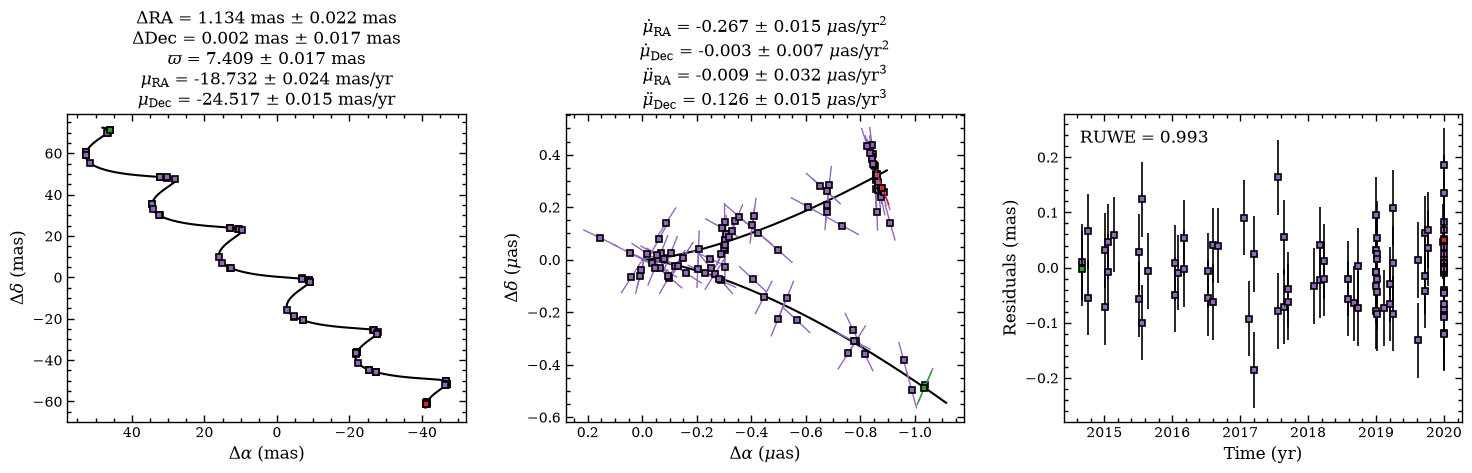

In [11]:
results = leastsq.accel_9param(plot_file='res_9param.png')

The RUWE decreased to 1.0 and the second-order proper motion derivative is quite well constrained.